In [1]:
import pandas as pd

base_path = "Tables_Created"

outlets = pd.read_csv(f"{base_path}/outlets.csv")
dishes = pd.read_csv(f"{base_path}/dishes.csv")
outlet_dish_mapping = pd.read_csv(f"{base_path}/outlet_dish_mapping.csv")
cuisines = pd.read_csv(f"{base_path}/cuisines.csv")
outlet_cuisine_mapping = pd.read_csv(f"{base_path}/outlet_cuisine_mapping.csv")
restaurant_types = pd.read_csv(f"{base_path}/restaurant_types.csv")
outlet_restaurant_type_mapping = pd.read_csv(f"{base_path}/outlet_restaurant_type_mapping.csv")
ratings = pd.read_csv(f"{base_path}/ratings.csv")


In [2]:
tables = {
    "outlets": outlets,
    "dishes": dishes,
    "outlet_dish_mapping": outlet_dish_mapping,
    "cuisines": cuisines,
    "outlet_cuisine_mapping": outlet_cuisine_mapping,
    "restaurant_types": restaurant_types,
    "outlet_restaurant_type_mapping": outlet_restaurant_type_mapping,
    "ratings": ratings
}

for name, table in tables.items():
    print(name, table.shape)

outlets (51717, 21)
dishes (2792, 2)
outlet_dish_mapping (128848, 4)
cuisines (77, 2)
outlet_cuisine_mapping (89393, 4)
restaurant_types (25, 2)
outlet_restaurant_type_mapping (59217, 4)
ratings (1320051, 5)


In [4]:
# Which restaurant brands/chains have the widest outlet presence in the dataset?
# number of unique outlets per restaurant name

top_restaurants_by_outlets = (
    outlets
    .groupby(["restaurant_id", "name"])["outlet_id"]
    .nunique()
    .reset_index(name="outlet_count")
    .sort_values("outlet_count", ascending=False)
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15172\818602127.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


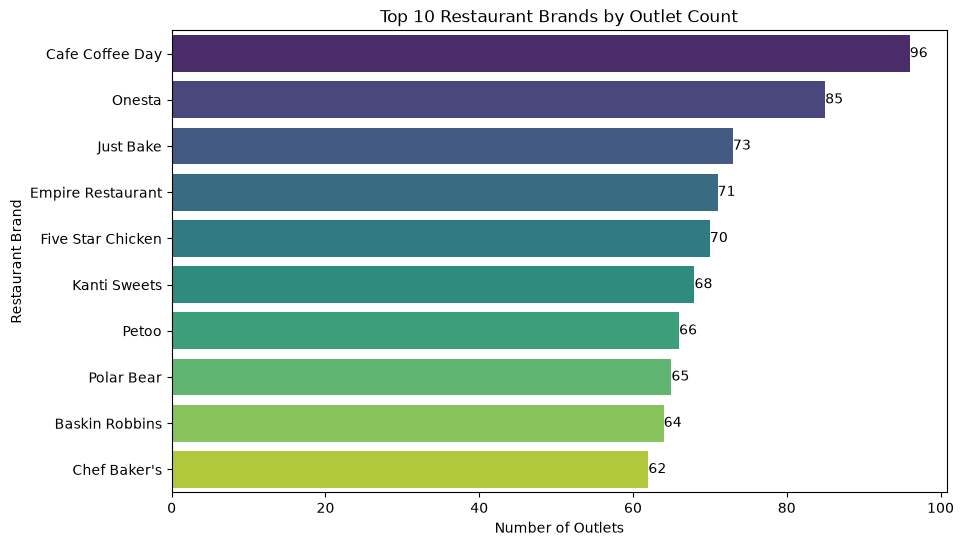

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

top_restaurants_by_outlets = (
    outlets
    .groupby(["restaurant_id", "name"])["outlet_id"]
    .nunique()
    .reset_index(name="outlet_count")
    .sort_values("outlet_count", ascending=False)
)

top_10_restaurants = top_restaurants_by_outlets.head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10_restaurants,
    x="outlet_count",
    y="name",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Restaurant Brands by Outlet Count")
plt.xlabel("Number of Outlets")
plt.ylabel("Restaurant Brand")

plt.show()

Cafe Coffee Day leads Bangalore in outlet presence with 96 outlets, followed by Onesta and Just Bake. The top brands are mostly cafe, bakery, dessert, and quick-service chains, suggesting strong coverage of casual food and snack-based outlets across the city.

This can connect to Bangalore’s cafe culture, office areas, quick meetups, and chain expansion.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15172\60797682.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


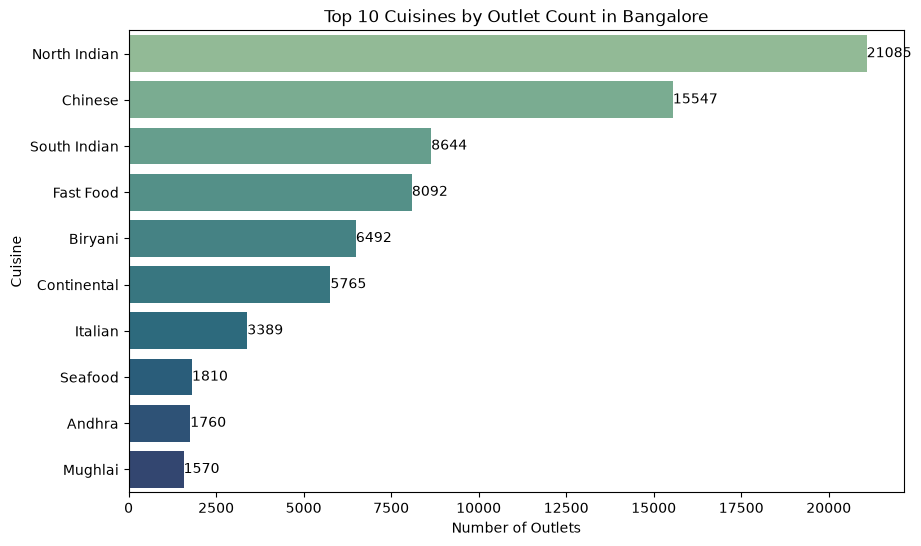

In [10]:
# Which cuisines have the widest availability across Bangalore?

cuisine_outlet_counts = (
    outlet_cuisine_mapping
    .groupby("cuisine_name")["outlet_id"]
    .nunique()
    .reset_index(name="outlet_count")
    .sort_values("outlet_count", ascending=False)
)

top_10_cuisines = cuisine_outlet_counts.head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10_cuisines,
    x="outlet_count",
    y="cuisine_name",
    palette="crest"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Cuisines by Outlet Count in Bangalore")
plt.xlabel("Number of Outlets")
plt.ylabel("Cuisine")

plt.show()

North Indian cuisine dominates outlet presence in Bangalore, followed by Chinese and South Indian. This may be influenced by Bangalore's diverse working and migrant population, including people from northern India.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15172\1342647138.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


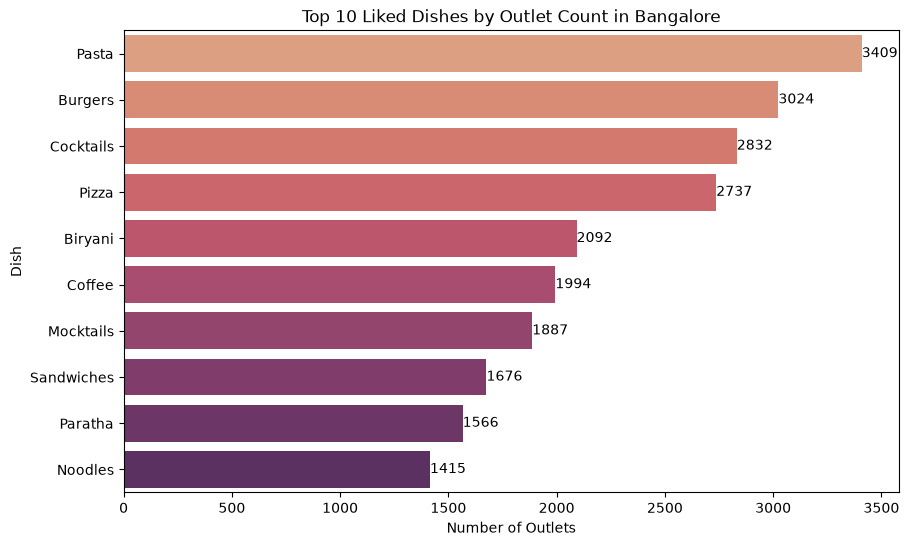

In [12]:
# Which dishes appear most frequently in the liked dishes field across Bangalore outlets?

dish_outlet_counts = (
    outlet_dish_mapping
    .groupby("dish_name")["outlet_id"]
    .nunique()
    .reset_index(name="outlet_count")
    .sort_values("outlet_count", ascending=False)
)

top_10_dishes = dish_outlet_counts.head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10_dishes,
    x="outlet_count",
    y="dish_name",
    palette="flare"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Liked Dishes by Outlet Count in Bangalore")
plt.xlabel("Number of Outlets")
plt.ylabel("Dish")

plt.show()

Pasta with leads the liked-dish in 3409 outlets across Bangalore outlets, followed by Burgers, Cocktails, Pizza, and Biryani. The top dishes show a mix of global casual food, beverages, and Indian comfort food, reflecting Bangalore's urban and diverse food culture. These counts represent liked-dish mentions across outlets, not actual sales volume.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15172\3630690046.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


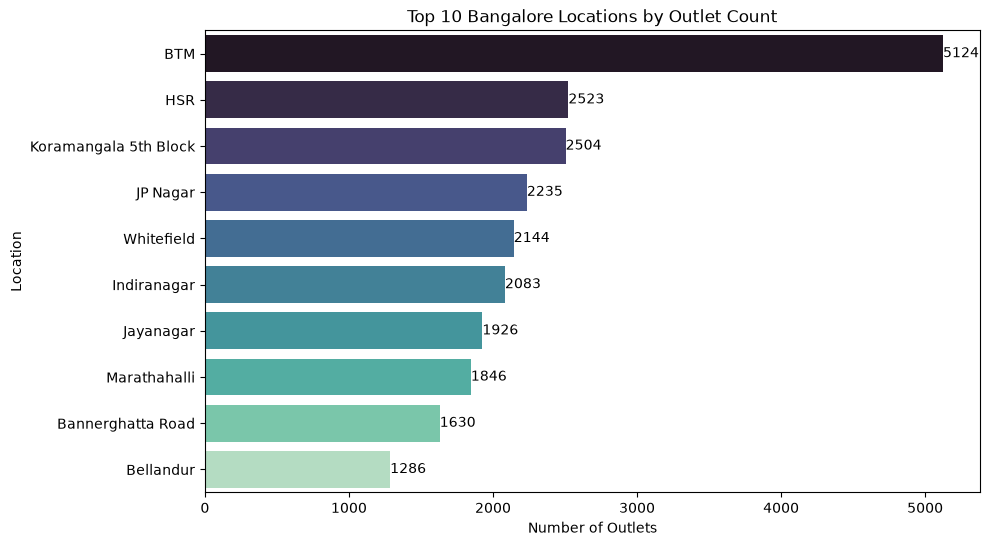

In [13]:
# Which Bangalore localities have the highest restaurant outlet concentration?

location_outlet_counts = (
    outlets
    .groupby("location")["outlet_id"]
    .nunique()
    .reset_index(name="outlet_count")
    .sort_values("outlet_count", ascending=False)
)

top_10_locations = location_outlet_counts.head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10_locations,
    x="outlet_count",
    y="location",
    palette="mako"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Bangalore Locations by Outlet Count")
plt.xlabel("Number of Outlets")
plt.ylabel("Location")

plt.show()

BTM has the highest outlet concentration in Bangalore with 5,124 outlets, almost double HSR with 2,523 and Koramangala 5th Block with 2,504.

The top locations are mostly busy residential, office, and commercial areas, suggesting that restaurant availability is higher around Bangalore’s major living and working hubs. This shows outlet presence, not direct customer demand.

In [ ]:
# Which outlet formats are most common in Bangalore?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15172\1892854000.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


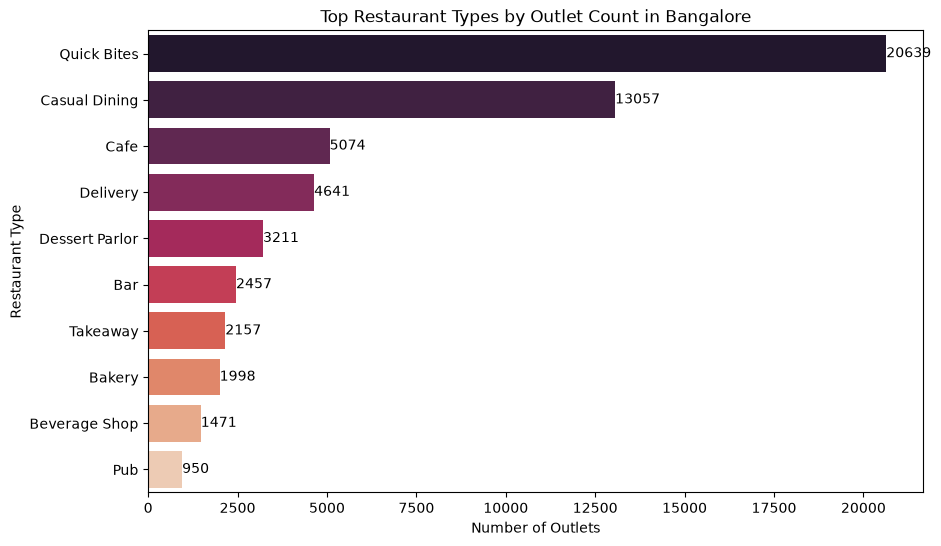

In [14]:
restaurant_type_outlet_counts = (
    outlet_restaurant_type_mapping
    .groupby("restaurant_type_name")["outlet_id"]
    .nunique()
    .reset_index(name="outlet_count")
    .sort_values("outlet_count", ascending=False)
)

top_restaurant_types = restaurant_type_outlet_counts.head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_restaurant_types,
    x="outlet_count",
    y="restaurant_type_name",
    palette="rocket"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top Restaurant Types by Outlet Count in Bangalore")
plt.xlabel("Number of Outlets")
plt.ylabel("Restaurant Type")

plt.show()

Quick Bites is the most common outlet format in Bangalore with 20,639 outlets, followed by Casual Dining with 13,057 outlets. Cafe, Delivery, and Dessert Parlor also have strong presence.

This suggests Bangalore’s restaurant market is heavily driven by everyday, casual, and convenience-based food formats rather than only premium dining. The presence of Delivery and Takeaway also reflects the city’s strong demand for quick and accessible food options.

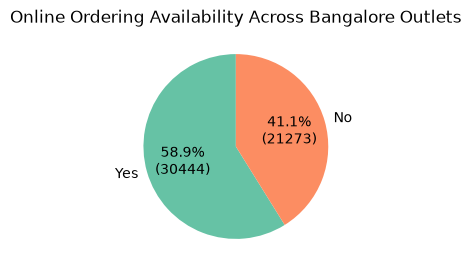

In [17]:
# How many Bangalore outlets support online ordering?

online_order_counts = (
    outlets
    .groupby("online_order")["outlet_id"]
    .nunique()
    .reset_index(name="outlet_count")
    .sort_values("outlet_count", ascending=False)
)

plt.figure(figsize=(3, 3))

plt.pie(
    online_order_counts["outlet_count"],
    labels=online_order_counts["online_order"],
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct / 100 * online_order_counts['outlet_count'].sum()))})",
    startangle=90,
    colors=sns.color_palette("Set2", len(online_order_counts))
)

plt.title("Online Ordering Availability Across Bangalore Outlets")
plt.show()

Around 58.9% of Bangalore outlets support online ordering, while 41.1% do not. This shows that online ordering is available in a majority of outlets, reflecting Bangalore’s strong food delivery and app-based ordering culture.

At the same time, a large 41.1% share still does not offer online ordering, which suggests that dine-in, takeaway, or offline-first restaurant formats continue to have a significant presence in the city.